In [1]:
import os
import numpy as np
import scipy.io as sio
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [ ]:
import sys
sys.path.append("..") 
from processing import  load_UCI_dataset, print_metrics, plot_regression_results, evaluate_minirocket_vitaldb

In [ ]:
X_train, y_train, X_val, y_val, X_test, y_test = load_UCI_dataset(
    WINDOW_SIZE=1000,
    STEP_SIZE=1000
)

BASE_DIR = "/data1/yashvi_bhuva/BP_estimation_using_PPG/VitalDB/ML/non_fiducial_features/8sec_0overlap/vitaldb_checkpoints"

Total recordings: 12000
Train recordings: 9600
Validation recordings: 1200
Test recordings: 1200


100%|██████████| 9600/9600 [01:22<00:00, 116.40it/s]


Skipped recordings: 107


100%|██████████| 1200/1200 [00:10<00:00, 112.55it/s]


Skipped recordings: 8


100%|██████████| 1200/1200 [00:11<00:00, 106.11it/s]


Skipped recordings: 9


In [ ]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (263103, 1, 1000)
y_train: (263103, 2)
X_val: (33223, 1, 1000)
y_val: (33223, 2)
X_test: (33347, 1, 1000)
y_test: (33347, 2)


In [7]:
from sktime.transformations.panel.rocket import MiniRocket

rocket = MiniRocket(num_kernels=10000, random_state=42)

rocket.fit(X_train)

MiniRocket(random_state=42)

In [8]:
X_train_rocket = rocket.transform(X_train)
X_val_rocket = rocket.transform(X_val)
X_test_rocket = rocket.transform(X_test)

print("X_train_rocket:", X_train_rocket.shape)
print("X_val_rocket:", X_val_rocket.shape)
print("X_test_rocket:", X_test_rocket.shape)

X_train_rocket: (263103, 9996)
X_val_rocket: (33223, 9996)
X_test_rocket: (33347, 9996)


In [9]:
np.save("X_train_minirocket.npy", X_train_rocket)
np.save("X_val_minirocket.npy", X_val_rocket)
np.save("X_test_minirocket.npy", X_test_rocket)

In [31]:
import numpy as np

X_train_rocket = np.load("X_train_minirocket.npy")
X_val_rocket = np.load("X_val_minirocket.npy")
X_test_rocket = np.load("X_test_minirocket.npy")

In [32]:
y_train_sbp = y_train[:, 0]
y_train_dbp = y_train[:, 1]

y_val_sbp = y_val[:, 0]
y_val_dbp = y_val[:, 1]

y_test_sbp = y_test[:, 0]
y_test_dbp = y_test[:, 1]

## RIDGE REGRESSION ##

In [12]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Hyperparameter grid
param_grid = {
    "alpha": [0.01, 0.1, 1, 10, 100, 1000, 10000]
}

# =========================
# SBP
# =========================
grid_ridge_sbp = GridSearchCV(
    estimator=Ridge(),
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=3,
    n_jobs=16,
    verbose=1
)

grid_ridge_sbp.fit(
    X_train_rocket,
    y_train[:, 0]
)

print("Best SBP parameters:")
print(grid_ridge_sbp.best_params_)

print("Best SBP CV RMSE:")
print((-grid_ridge_sbp.best_score_) ** 0.5)


# =========================
# DBP
# =========================
grid_ridge_dbp = GridSearchCV(
    estimator=Ridge(),
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=3,
    n_jobs=16,
    verbose=1
)

grid_ridge_dbp.fit(
    X_train_rocket,
    y_train[:, 1]
)

print("\nBest DBP parameters:")
print(grid_ridge_dbp.best_params_)

print("Best DBP CV RMSE:")
print((-grid_ridge_dbp.best_score_) ** 0.5)

Fitting 3 folds for each of 7 candidates, totalling 21 fits
Best SBP parameters:
{'alpha': 10}
Best SBP CV RMSE:
17.514522725836372
Fitting 3 folds for each of 7 candidates, totalling 21 fits

Best DBP parameters:
{'alpha': 10}
Best DBP CV RMSE:
8.965690185228421


In [13]:
y_pred_sbp = grid_ridge_sbp.predict(X_test_rocket)
y_pred_dbp = grid_ridge_dbp.predict(X_test_rocket)

In [14]:
print("MiniRocket + Ridge — SBP")
print("------------------------")
print_metrics(y_test_sbp, y_pred_sbp)

print("\nMiniRocket + Ridge — DBP")
print("------------------------")
print_metrics(y_test_dbp, y_pred_dbp)

MiniRocket + Ridge — SBP
------------------------
RMSE: 17.3590
MSE : 301.3352
R²  : 0.4294
MAE : 13.1578

MiniRocket + Ridge — DBP
------------------------
RMSE: 8.9274
MSE : 79.6984
R²  : 0.3620
MAE : 6.4483


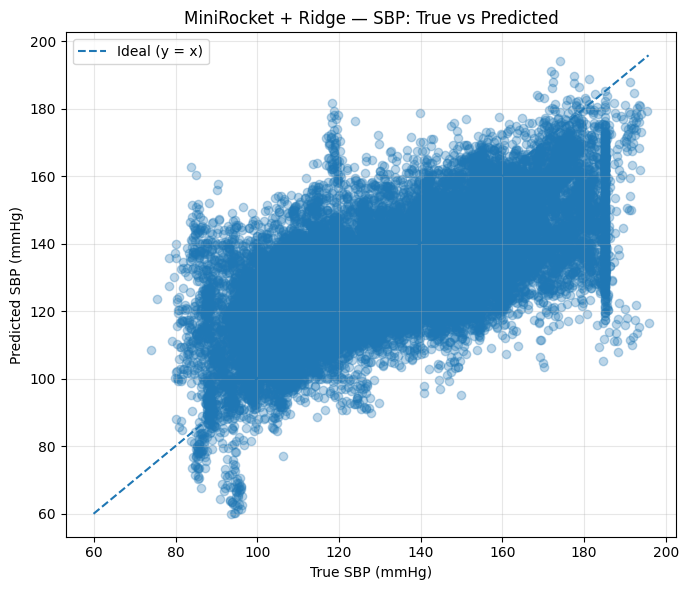

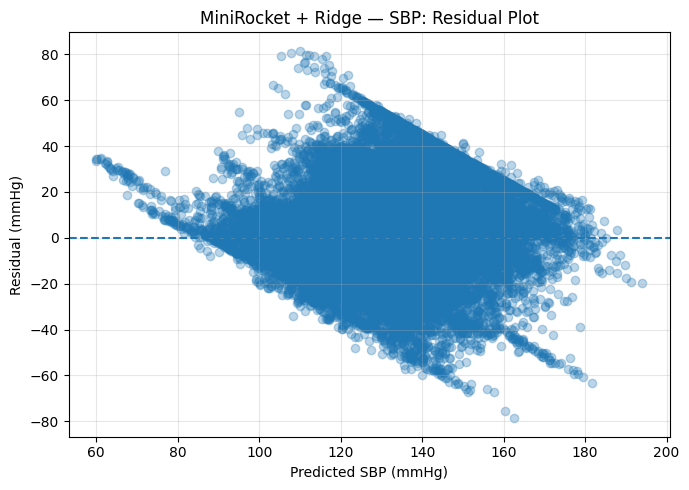

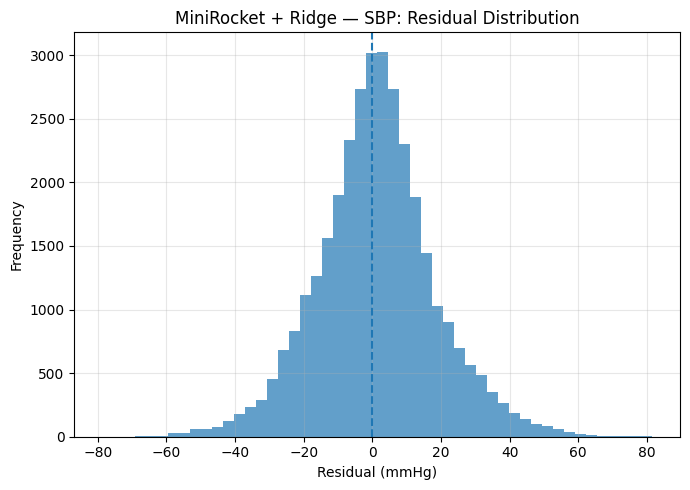

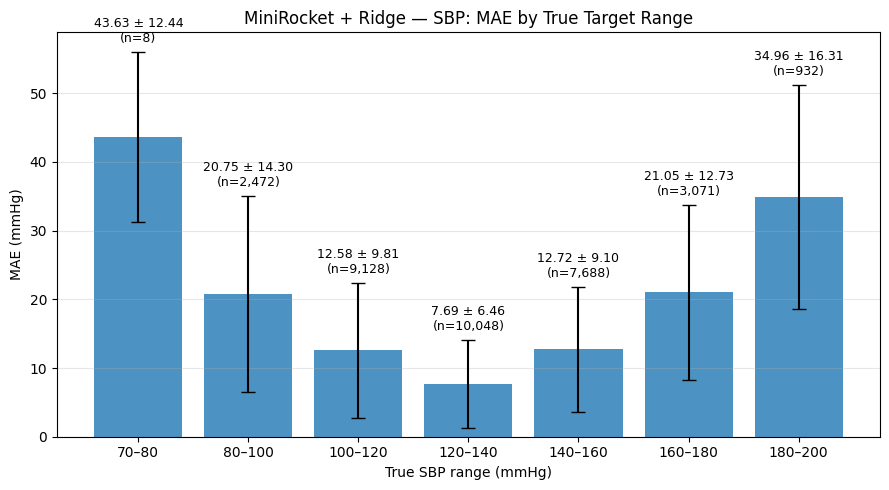

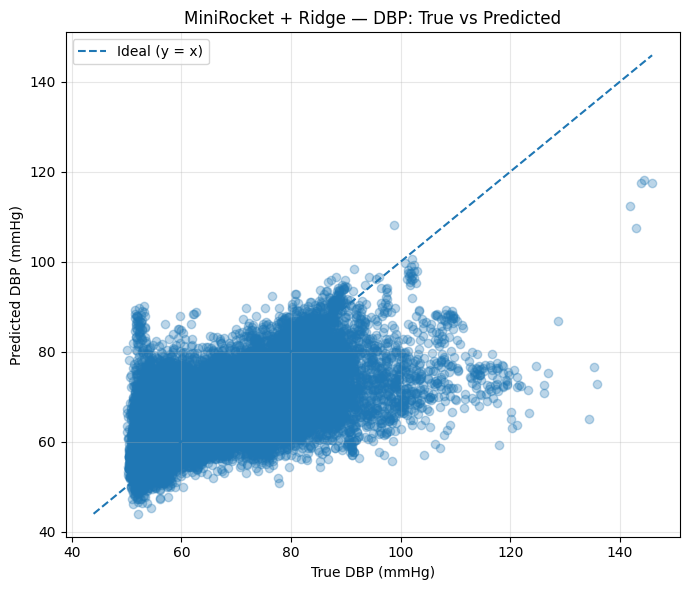

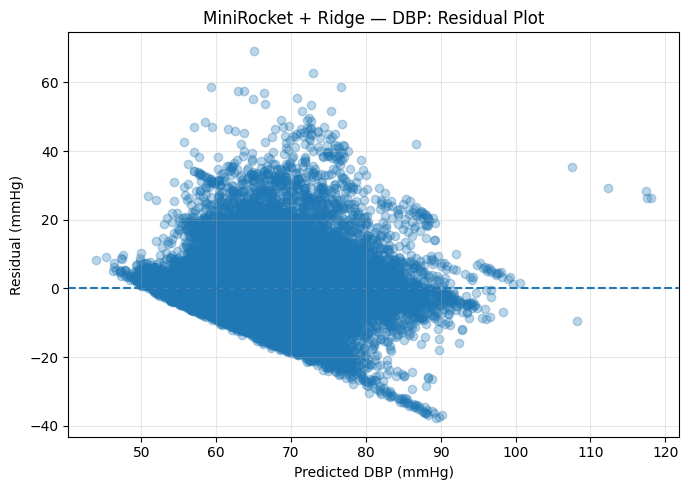

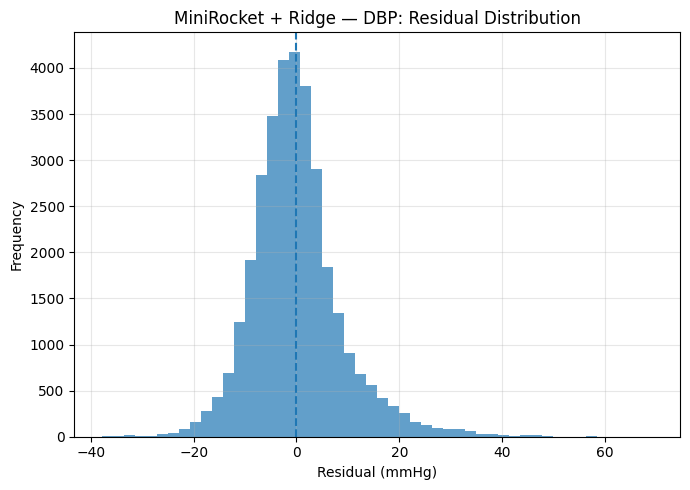

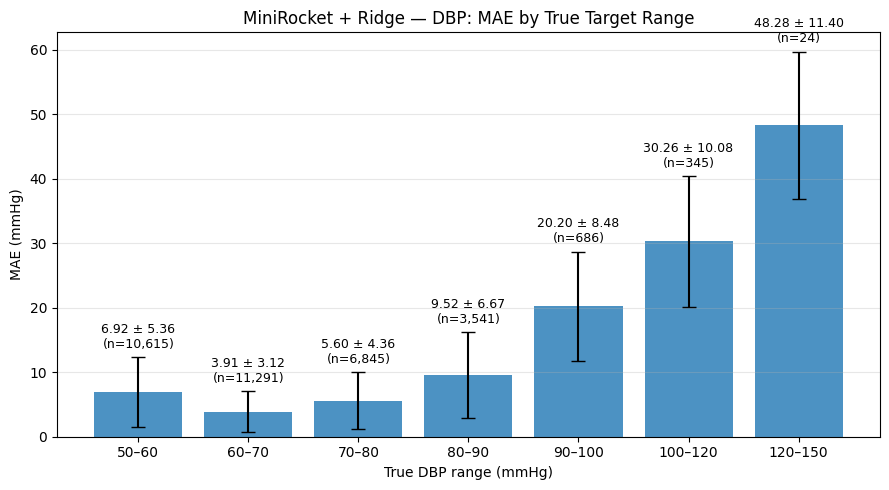

In [15]:
plot_regression_results(
    y_test_sbp,
    y_pred_sbp,
    "MiniRocket + Ridge",
    "SBP"
)

plot_regression_results(
    y_test_dbp,
    y_pred_dbp,
    "MiniRocket + Ridge",
    "DBP"
)

Number of VitalDB cases: 1968


MiniROCKET VitalDB prediction: 100%|██████████| 1968/1968 [48:16<00:00,  1.47s/case] 




MiniROCKET + ElasticNet
VITALDB ZERO-SHOT RESULTS

SBP
------------------------------
RMSE: 23.6668
MSE : 560.1158
R²  : -0.3148
MAE : 18.5274

DBP
------------------------------
RMSE: 14.8035
MSE : 219.1449
R²  : -0.3539
MAE : 11.4474


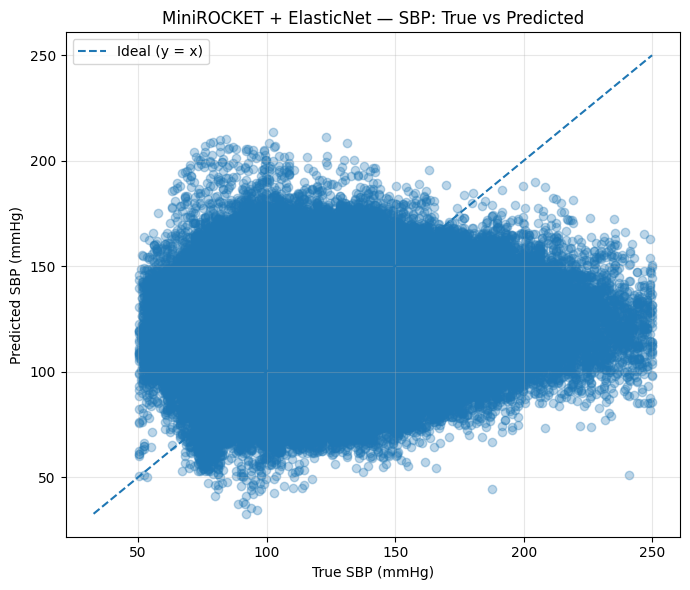

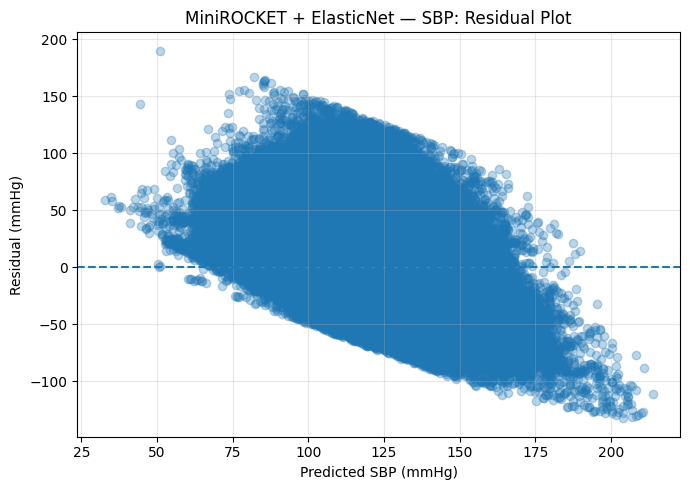

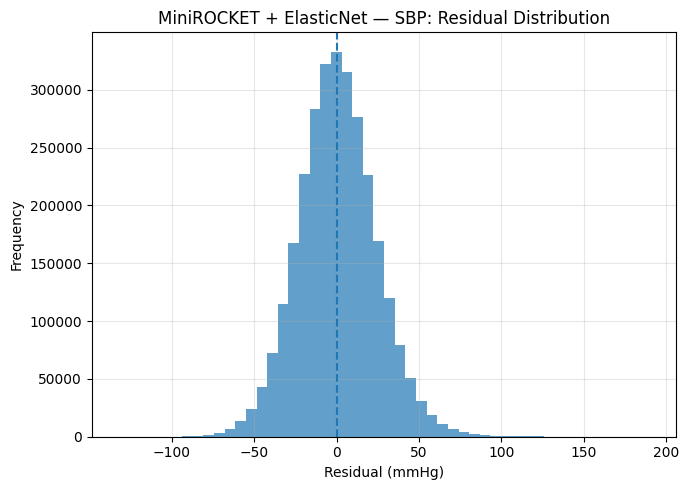

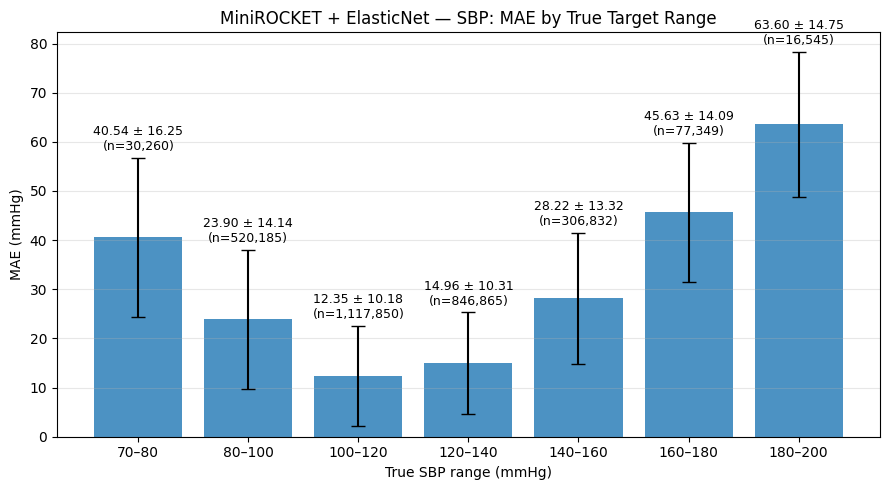

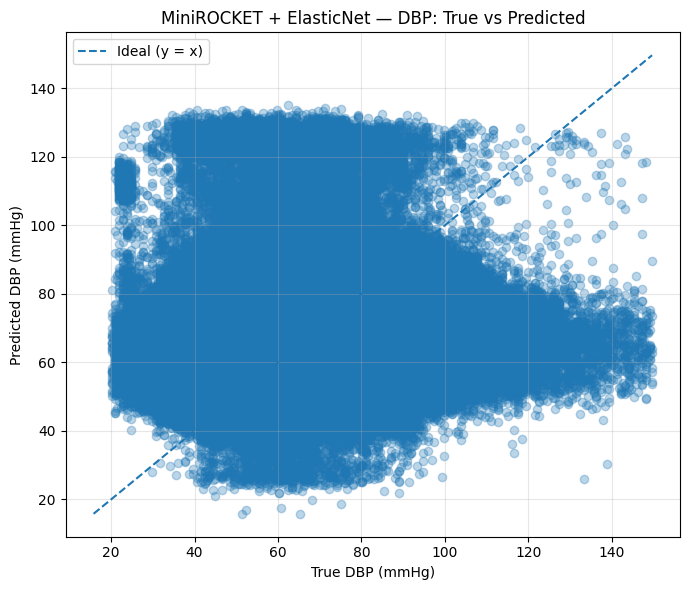

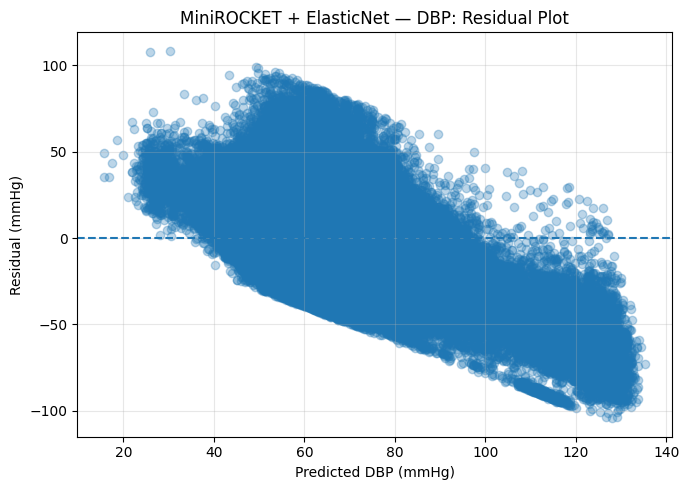

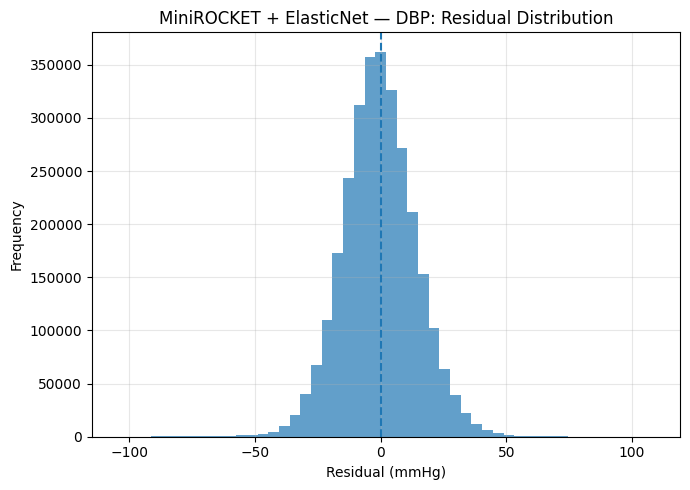

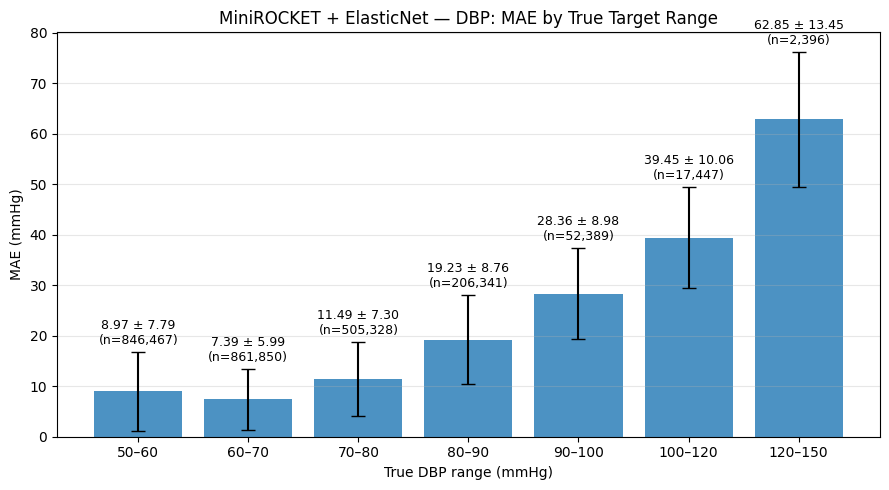


Final prediction shape:
(2928374, 5)

First 5 predictions:
  case_id    SBP_true    SBP_pred   DBP_true   DBP_pred
0  case_1  169.920013  124.825104  77.099091  55.691772
1  case_1  170.907501  130.339874  75.124176  60.174866
2  case_1  169.920013  124.744110  75.124176  56.109528
3  case_1  169.426300  119.270966  75.124176  52.138901
4  case_1  166.957672  124.136322  75.124176  56.786682


In [28]:
results_vitaldb = evaluate_minirocket_vitaldb(
    base_dir=BASE_DIR,
    rocket=rocket,
    best_en_sbp=grid_ridge_sbp,
    best_en_dbp=grid_ridge_dbp,
    batch_size=5000
)

## ELASTIC NET ##

In [33]:
import numpy as np
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV

# --------------------------------------------------
# Use a subset ONLY for hyperparameter tuning due  to large dataset size
# --------------------------------------------------
rng = np.random.RandomState(42)

n_tune = min(20000, len(X_train_rocket))
tune_idx = rng.choice(
    len(X_train_rocket),
    size=n_tune,
    replace=False
)

X_tune = X_train_rocket.iloc[tune_idx] if hasattr(X_train_rocket, "iloc") else X_train_rocket[tune_idx]

y_tune_sbp = y_train[tune_idx, 0]
y_tune_dbp = y_train[tune_idx, 1]

print("ElasticNet tuning data:", X_tune.shape)

elastic_net = ElasticNet(
    max_iter=2000,
    random_state=42
)

param_grid_en = {
    "alpha": [0.01, 0.05, 0.1],
    "l1_ratio": [0.1, 0.5, 0.9]
}

grid_en_sbp = GridSearchCV(
    estimator=elastic_net,
    param_grid=param_grid_en,
    scoring="neg_mean_squared_error",
    cv=3,
    n_jobs=16,
    verbose=1
)

grid_en_sbp.fit(X_tune, y_tune_sbp)

print("Best SBP parameters:", grid_en_sbp.best_params_)
print(
    "Best SBP CV RMSE:",
    np.sqrt(-grid_en_sbp.best_score_)
)


grid_en_dbp = GridSearchCV(
    estimator=elastic_net,
    param_grid=param_grid_en,
    scoring="neg_mean_squared_error",
    cv=3,
    n_jobs=16,
    verbose=1
)

grid_en_dbp.fit(X_tune, y_tune_dbp)

print("Best DBP parameters:", grid_en_dbp.best_params_)
print(
    "Best DBP CV RMSE:",
    np.sqrt(-grid_en_dbp.best_score_)
)

ElasticNet tuning data: (20000, 9996)
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Best SBP parameters: {'alpha': 0.01, 'l1_ratio': 0.9}
Best SBP CV RMSE: 18.46799482037078
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Best DBP parameters: {'alpha': 0.01, 'l1_ratio': 0.1}
Best DBP CV RMSE: 9.401630492132542


In [ ]:
best_en_sbp = ElasticNet(
    alpha=grid_en_sbp.best_params_["alpha"],
    l1_ratio=grid_en_sbp.best_params_["l1_ratio"],
    max_iter=2000,
    random_state=42
)

best_en_dbp = ElasticNet(
    alpha=grid_en_dbp.best_params_["alpha"],
    l1_ratio=grid_en_dbp.best_params_["l1_ratio"],
    max_iter=2000,
    random_state=42
)

best_en_sbp.fit(X_train_rocket, y_train[:, 0])
best_en_dbp.fit(X_train_rocket, y_train[:, 1])

In [ ]:
print("SBP iterations:", best_en_sbp.n_iter_)
print("DBP iterations:", best_en_dbp.n_iter_)

SBP iterations: 2000
DBP iterations: 2000


In [ ]:
y_pred_en_sbp = best_en_sbp.predict(X_test_rocket)
y_pred_en_dbp = best_en_dbp.predict(X_test_rocket)

In [ ]:
print("ElasticNet — SBP")
print("----------------")
print_metrics(y_test[:, 0], y_pred_en_sbp)

print("\nElasticNet — DBP")
print("----------------")
print_metrics(y_test[:, 1], y_pred_en_dbp)

ElasticNet — SBP
----------------
RMSE: 18.8531
MSE : 355.4381
R²  : 0.3271
MAE : 14.8604

ElasticNet — DBP
----------------
RMSE: 9.5430
MSE : 91.0695
R²  : 0.2727
MAE : 7.2740


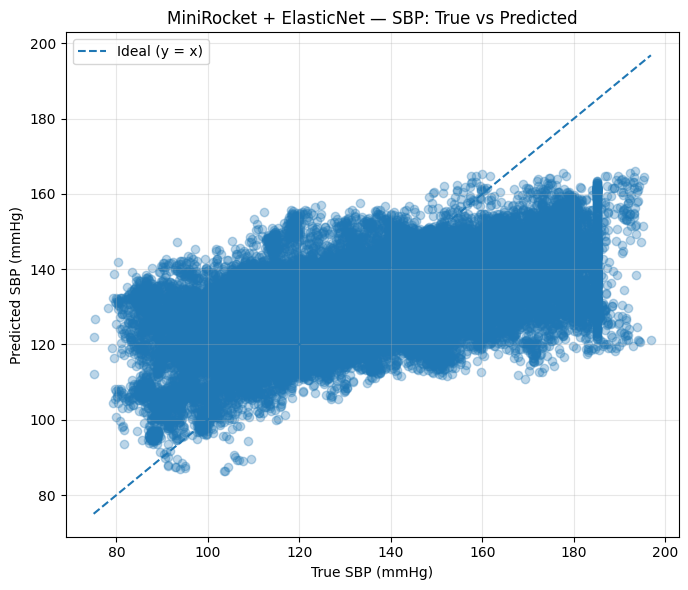

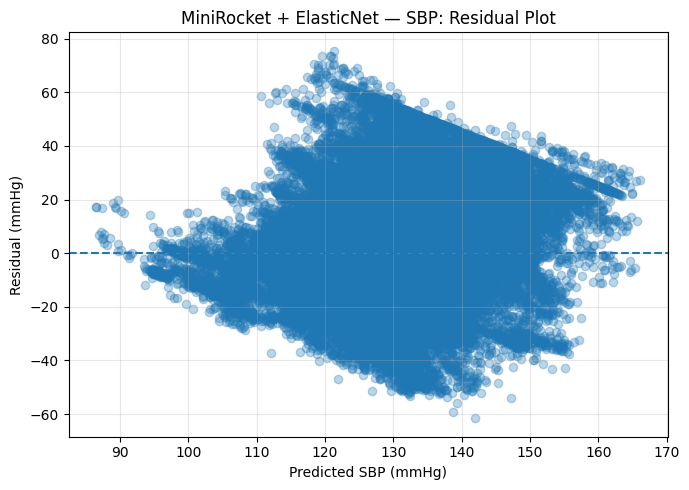

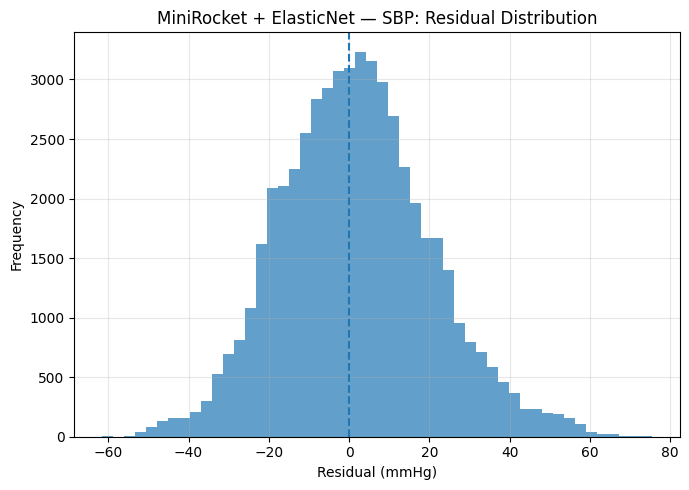

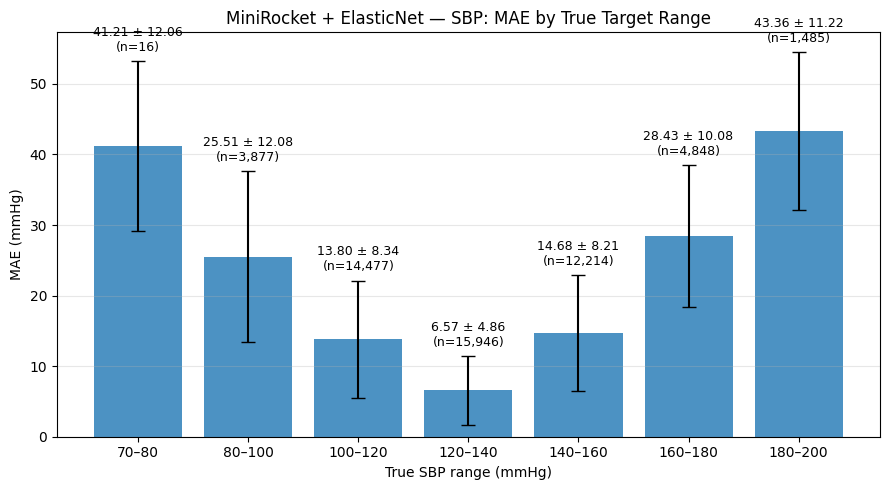

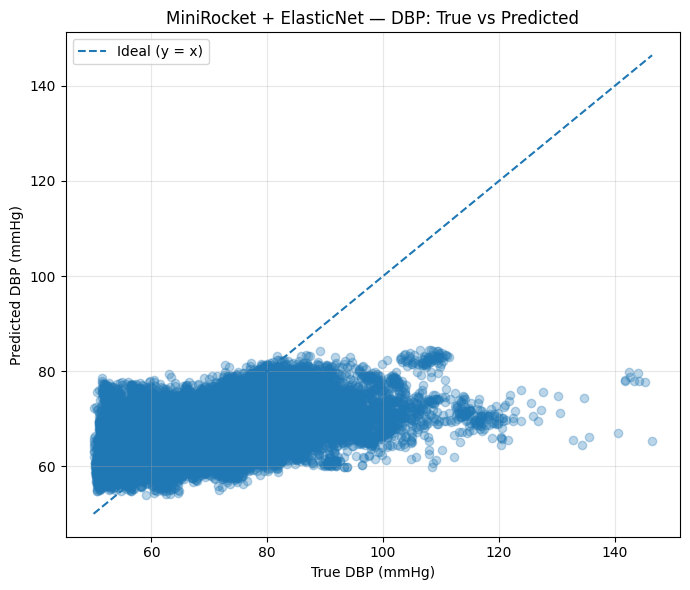

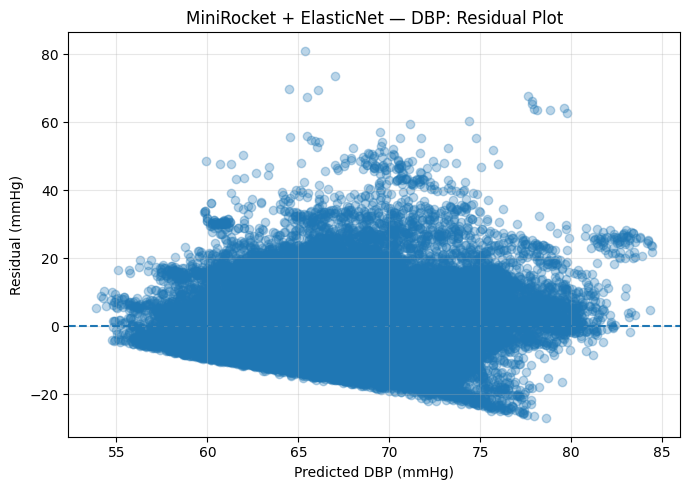

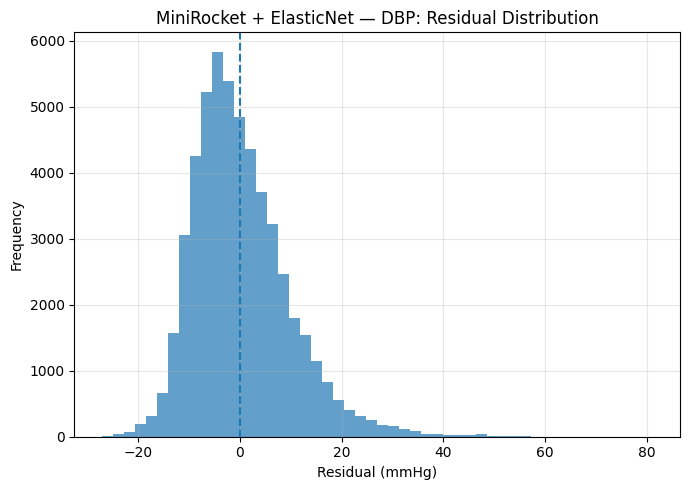

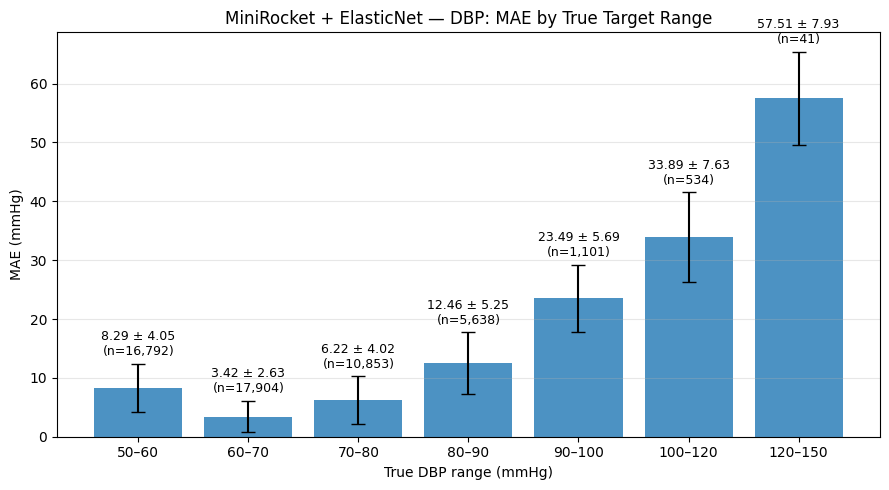

In [15]:
plot_regression_results(
    y_test_sbp,
    y_pred_en_sbp,
    "MiniRocket + ElasticNet",
    "SBP"
)

plot_regression_results(
    y_test_dbp,
    y_pred_en_dbp,
    "MiniRocket + ElasticNet",
    "DBP"
)

In [ ]:
results_vitaldb = evaluate_minirocket_vitaldb(
    base_dir=BASE_DIR,
    rocket=rocket,
    best_en_sbp=best_en_sbp,
    best_en_dbp=best_en_dbp,
    batch_size=5000
)